In [ ]:
# Load and Setup Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_DIR = "."
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_val   = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze("columns")
y_val   = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze("columns")
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")
 
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

CAT_COL = "Country Name"
 
X_train_enc = pd.get_dummies(X_train, columns=[CAT_COL], prefix="country")
X_val_enc   = pd.get_dummies(X_val,   columns=[CAT_COL], prefix="country")
X_test_enc  = pd.get_dummies(X_test,  columns=[CAT_COL], prefix="country")
 
# Align columns: any country present in val/test but not train -> drop;
# any present in train but missing from val/test -> add as 0.
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
 
print(f"After encoding: {X_train_enc.shape[1]} features")

def evaluate(model, X, y, label):
    pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    print(f"  {label:5s}  RMSE={rmse:10.3f}   MAE={mae:10.3f}   R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

Train: (1449, 18)  Val: (484, 18)  Test: (484, 18)
After encoding: 149 features


In [ ]:
# Decision Tree Regression

dt_results = []
for depth in [3, 5, 7, 10, 15, 20, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_enc, y_train)
    val_pred = dt.predict(X_val_enc)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2   = r2_score(y_val, val_pred)
    dt_results.append({"max_depth": depth, "val_rmse": val_rmse, "val_r2": val_r2})
    print(f"  max_depth={str(depth):>4s}   val RMSE={val_rmse:10.3f}   val R²={val_r2:.4f}")
 
dt_df = pd.DataFrame(dt_results)
best_dt_depth_raw = dt_df.loc[dt_df["val_rmse"].idxmin(), "max_depth"]
best_dt_depth = None if pd.isna(best_dt_depth_raw) else int(best_dt_depth_raw)
print(f"\n  → Best max_depth (lowest val RMSE): {best_dt_depth}")

best_dt = DecisionTreeRegressor(max_depth=best_dt_depth, random_state=42)
best_dt.fit(X_train_enc, y_train)
print("Final Decision Tree performance:")
evaluate(best_dt, X_train_enc, y_train, "Train")
evaluate(best_dt, X_val_enc,   y_val,   "Val")
dt_test_metrics = evaluate(best_dt, X_test_enc, y_test, "Test")

  max_depth=   3   val RMSE=   177.214   val R²=0.9564
  max_depth=   5   val RMSE=    89.004   val R²=0.9890
  max_depth=   7   val RMSE=    75.012   val R²=0.9922
  max_depth=  10   val RMSE=    58.091   val R²=0.9953
  max_depth=  15   val RMSE=    56.746   val R²=0.9955
  max_depth=  20   val RMSE=    55.004   val R²=0.9958
  max_depth=None   val RMSE=    56.842   val R²=0.9955

  → Best max_depth (lowest val RMSE): 20
Final Decision Tree performance:
  Train  RMSE=     0.446   MAE=     0.131   R²=1.0000
  Val    RMSE=    55.004   MAE=    14.134   R²=0.9958
  Test   RMSE=    92.117   MAE=    20.262   R²=0.9947


In [ ]:
# Random Forest Regression

rf_results = []
for n_est in [100, 300]:
    for depth in [10, 20, None]:
        for min_leaf in [1, 2]:
            rf = RandomForestRegressor(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=min_leaf,
                n_jobs=-1,
                random_state=42,
            )
            rf.fit(X_train_enc, y_train)
            val_pred = rf.predict(X_val_enc)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
            val_r2   = r2_score(y_val, val_pred)
            rf_results.append({
                "n_estimators": n_est, "max_depth": depth,
                "min_samples_leaf": min_leaf,
                "val_rmse": val_rmse, "val_r2": val_r2,
            })
            print(f"  n_est={n_est:3d}  depth={str(depth):>4s}  "
                  f"min_leaf={min_leaf}   val RMSE={val_rmse:10.3f}   val R²={val_r2:.4f}")
 
rf_df = pd.DataFrame(rf_results)
best_rf_row = rf_df.loc[rf_df["val_rmse"].idxmin()]
print(f"\n  → Best RF config: {best_rf_row.to_dict()}")

best_rf = RandomForestRegressor(
    n_estimators=int(best_rf_row["n_estimators"]),
    max_depth=None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"]),
    min_samples_leaf=int(best_rf_row["min_samples_leaf"]),
    n_jobs=-1,
    random_state=42,
)
best_rf.fit(X_train_enc, y_train)
print("Final Random Forest performance:")
evaluate(best_rf, X_train_enc, y_train, "Train")
evaluate(best_rf, X_val_enc,   y_val,   "Val")
rf_test_metrics = evaluate(best_rf, X_test_enc, y_test, "Test")

  n_est=100  depth=  10  min_leaf=1   val RMSE=    42.014   val R²=0.9976
  n_est=100  depth=  10  min_leaf=2   val RMSE=    42.978   val R²=0.9974
  n_est=100  depth=  20  min_leaf=1   val RMSE=    42.688   val R²=0.9975
  n_est=100  depth=  20  min_leaf=2   val RMSE=    43.572   val R²=0.9974
  n_est=100  depth=None  min_leaf=1   val RMSE=    41.649   val R²=0.9976
  n_est=100  depth=None  min_leaf=2   val RMSE=    39.722   val R²=0.9978
  n_est=300  depth=  10  min_leaf=1   val RMSE=    41.625   val R²=0.9976
  n_est=300  depth=  10  min_leaf=2   val RMSE=    42.703   val R²=0.9975
  n_est=300  depth=  20  min_leaf=1   val RMSE=    41.656   val R²=0.9976
  n_est=300  depth=  20  min_leaf=2   val RMSE=    42.132   val R²=0.9975
  n_est=300  depth=None  min_leaf=1   val RMSE=    41.803   val R²=0.9976
  n_est=300  depth=None  min_leaf=2   val RMSE=    42.171   val R²=0.9975

  → Best RF config: {'n_estimators': 100.0, 'max_depth': nan, 'min_samples_leaf': 2.0, 'val_rmse': 39.721542450

In [ ]:
# Feature Importances

importances = (
    pd.Series(best_rf.feature_importances_, index=X_train_enc.columns)
    .sort_values(ascending=False)
    .head(15)
)
print(importances.to_string(float_format=lambda x: f"{x:.4f}"))
 

Urban population                                                 0.7194
country_China                                                    0.0929
Net trade in goods and services (BoP, current US$)               0.0637
country_United States                                            0.0267
Electric power consumption (kWh per capita)                      0.0177
Agriculture, forestry, and fishing, value added (% of GDP)       0.0144
Urban population (% of total population)                         0.0110
GDP (constant LCU)                                               0.0099
country_India                                                    0.0077
GDP (current LCU)                                                0.0066
country_Russian Federation                                       0.0058
Electricity production from coal sources (% of total)            0.0049
Electricity production from hydroelectric sources (% of total)   0.0038
Access to electricity, rural (% of rural population)            

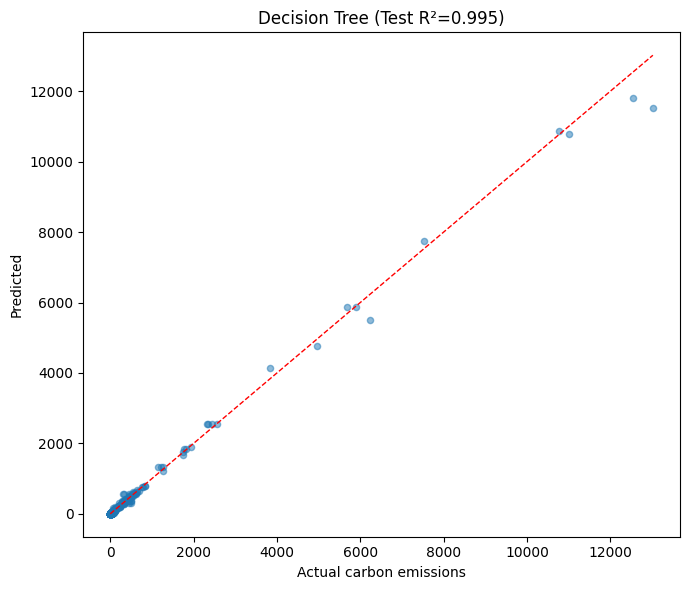

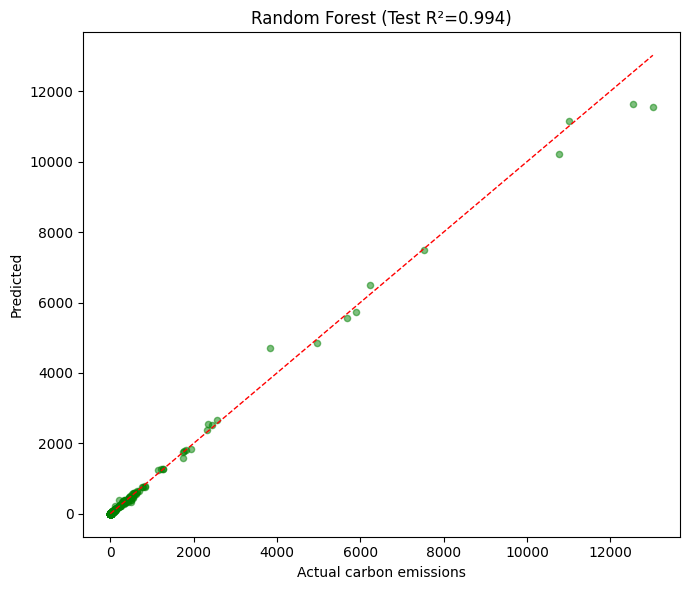

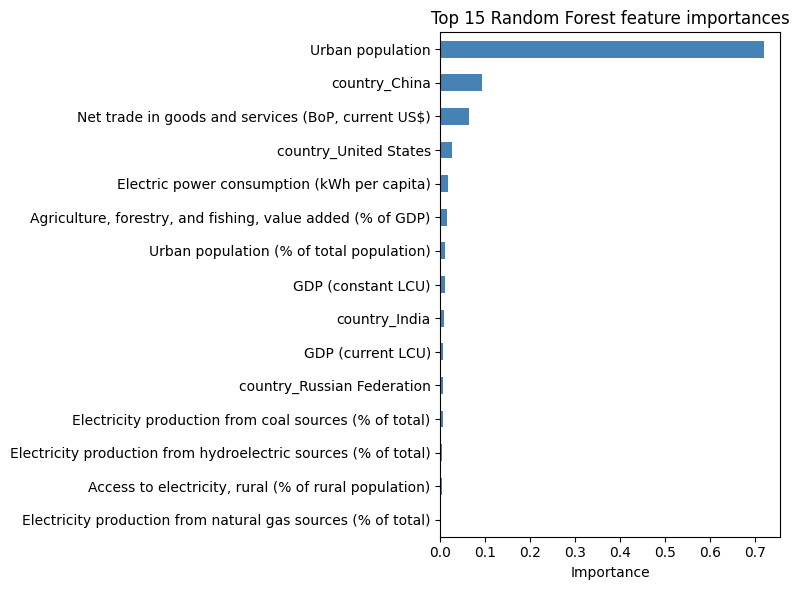

In [ ]:
# Plots

dt_pred = best_dt.predict(X_test_enc)
rf_pred = best_rf.predict(X_test_enc)
lims = [
    min(y_test.min(), dt_pred.min(), rf_pred.min()),
    max(y_test.max(), dt_pred.max(), rf_pred.max()),
]
 
plt.figure(figsize=(7, 6))
plt.scatter(y_test, dt_pred, alpha=0.5, s=20)
plt.plot(lims, lims, "r--", lw=1)
plt.xlabel("Actual carbon emissions")
plt.ylabel("Predicted")
plt.title(f"Decision Tree (Test R²={dt_test_metrics['r2']:.3f})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, s=20, color="green")
plt.plot(lims, lims, "r--", lw=1)
plt.xlabel("Actual carbon emissions")
plt.ylabel("Predicted")
plt.title(f"Random Forest (Test R²={rf_test_metrics['r2']:.3f})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
importances[::-1].plot(kind="barh", color="steelblue")
plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()